<a href="https://colab.research.google.com/github/rahna1369/Car-Price-Prediction-ML/blob/main/CarPrice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [192]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [193]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

In [194]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import GridSearchCV

### LOADING AND PREPROCESSING

Load the data and transform it so the machine learning algorithms can read it without errors.

In [195]:
df = pd.read_csv('CarPrice_Assignment.csv')
print(df.head())


   car_ID  symboling                   CarName fueltype aspiration doornumber  \
0       1          3        alfa-romero giulia      gas        std        two   
1       2          3       alfa-romero stelvio      gas        std        two   
2       3          1  alfa-romero Quadrifoglio      gas        std        two   
3       4          2               audi 100 ls      gas        std       four   
4       5          2                audi 100ls      gas        std       four   

       carbody drivewheel enginelocation  wheelbase  ...  enginesize  \
0  convertible        rwd          front       88.6  ...         130   
1  convertible        rwd          front       88.6  ...         130   
2    hatchback        rwd          front       94.5  ...         152   
3        sedan        fwd          front       99.8  ...         109   
4        sedan        4wd          front       99.4  ...         136   

   fuelsystem  boreratio  stroke compressionratio horsepower  peakrpm citympg  \

In [196]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    object 
 3   fueltype          205 non-null    object 
 4   aspiration        205 non-null    object 
 5   doornumber        205 non-null    object 
 6   carbody           205 non-null    object 
 7   drivewheel        205 non-null    object 
 8   enginelocation    205 non-null    object 
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    object 
 15  cylindernumber    205 non-null    object 
 16  enginesize        205 non-null    int64  
 1

In [197]:
df.describe()

,car_ID,symboling,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
count,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
mean,103.000000,0.834146,98.756585,174.049268,65.907805,53.724878,2555.565854,126.907317,3.329756,3.255415,10.142537,104.117073,5125.121951,25.219512,30.751220,13276.710571
std,59.322565,1.245307,6.021776,12.337289,2.145204,2.443522,520.680204,41.642693,0.270844,0.313597,3.972040,39.544167,476.985643,6.542142,6.886443,7988.852332
min,1.000000,-2.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,52.000000,0.000000,94.500000,166.300000,64.100000,52.000000,2145.000000,97.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7788.000000
50%,103.000000,1.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5200.000000,24.000000,30.000000,10295.000000
75%,154.000000,2.000000,102.400000,183.100000,66.900000,55.500000,2935.000000,141.000000,3.580000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16503.000000
max,205.000000,3.000000,120.900000,208.100000,72.300000,59.800000,4066.000000,326.000000,3.940000,4.170000,23.000000,288.000000,6600.000000,49.000000,54.000000,45400.000000


In [198]:
print(f"Dataset loaded successfully with {df.shape[0]} rows and {df.shape[1]} columns.\n")
print("Columns in dataset:", df.columns.tolist())

Dataset loaded successfully with 205 rows and 26 columns.

Columns in dataset: ['car_ID', 'symboling', 'CarName', 'fueltype', 'aspiration', 'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'wheelbase', 'carlength', 'carwidth', 'carheight', 'curbweight', 'enginetype', 'cylindernumber', 'enginesize', 'fuelsystem', 'boreratio', 'stroke', 'compressionratio', 'horsepower', 'peakrpm', 'citympg', 'highwaympg', 'price']


In [199]:
print(df.isnull().sum())

car_ID              0
symboling           0
CarName             0
fueltype            0
aspiration          0
doornumber          0
carbody             0
drivewheel          0
enginelocation      0
wheelbase           0
carlength           0
carwidth            0
carheight           0
curbweight          0
enginetype          0
cylindernumber      0
enginesize          0
fuelsystem          0
boreratio           0
stroke              0
compressionratio    0
horsepower          0
peakrpm             0
citympg             0
highwaympg          0
price               0
dtype: int64


**Feature Separation:** The target column (price) is separated from the independent features. Column identifiers like car_ID , CarName are dropped since they have no predictive value.

In [200]:
X = df.drop(columns=['price','car_ID','CarName'],errors='ignore')
# Assuming price is the target variable
y = df['price']


**Handling Text Data:** Categorical text columns are transformed into numbers (0s and 1s) using One-Hot Encoding.

​**Handling Numeric Data:** Numeric columns are scaled using StandardScaler to ensure all features have a mean of 0 and variance of 1, keeping the scales uniform.

In [201]:
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()
print(f"Numerical Features identified ({len(numeric_features)}): {numeric_features}")
print(f"Categorical Feature identified ({len(categorical_features)}):{categorical_features}")


Numerical Features identified (14): ['symboling', 'wheelbase', 'carlength', 'carwidth', 'carheight', 'curbweight', 'enginesize', 'boreratio', 'stroke', 'compressionratio', 'horsepower', 'peakrpm', 'citympg', 'highwaympg']
Categorical Feature identified (9):['fueltype', 'aspiration', 'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'enginetype', 'cylindernumber', 'fuelsystem']


In [202]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first'))])

preprocessor = ColumnTransformer(transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)])

**Data Splitting:** Data is divided into 80% for training (to teach the models) and 20% for testing (to validate their accuracy).

In [203]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")
print("Preprocessing pipelines successfully constructed.\n")

Training features shape: (164, 23)
Testing features shape: (41, 23)
Preprocessing pipelines successfully constructed.



### MODEL IMPLEMENTATION & EVALUATION

Implement five regression algorithms and compare how accurately they predict car prices.

In [204]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "Support Vector Regressor": SVR(kernel='rbf')
}

results = []
for name, model in models.items():
    model_pipeline = Pipeline(steps=[('preprocessor', preprocessor),('regressor', model)])

    model_pipeline.fit(X_train, y_train)  # Train
    y_pred = model_pipeline.predict(X_test)  # Predict

    r2 = r2_score(y_test, y_pred)  # Evaluate
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)

    results.append({
        "Model": name,
        "R-squared": round(r2, 4),
        "MSE": round(mse, 2),
        "MAE": round(mae, 2)
    })
    print(f"Successfully trained and evaluated: {name}")


Successfully trained and evaluated: Linear Regression
Successfully trained and evaluated: Decision Tree


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [7] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [7] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


Successfully trained and evaluated: Random Forest
Successfully trained and evaluated: Gradient Boosting
Successfully trained and evaluated: Support Vector Regressor


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [7] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [7] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [7] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [205]:
# Convert results to a DataFrame for easy comparison
df_results = pd.DataFrame(results)
df_results = df_results.sort_values(by="R-squared", ascending=False).reset_index(drop=True)

print("\nFINAL MODEL PERFORMANCE METRICS")
print(df_results.to_string(index=False))

# Identify the best model dynamically
best_model_name = df_results.loc[0, 'Model']
best_model_r2 = df_results.loc[0, 'R-squared']
print(f"\n The best performing model is '{best_model_name}' with an R-squared score of {best_model_r2}.\n")


FINAL MODEL PERFORMANCE METRICS
                   Model  R-squared         MSE     MAE
           Random Forest     0.9588  3255047.99 1268.41
       Gradient Boosting     0.9265  5799416.49 1670.46
       Linear Regression     0.8926  8482008.48 2089.38
           Decision Tree     0.8879  8851015.14 1991.04
Support Vector Regressor    -0.0996 86810432.28 5694.27

 The best performing model is 'Random Forest' with an R-squared score of 0.9588.



**Performance Assessment**: The Tree-based ensemble models (Random Forest / Gradient Boosting) significantly outperform simple structural alternatives like Linear Regression and Support Vector Machines.

​**Justification**: Random Forest yields the highest R-squared (R^2), meaning it explains the maximum variance of car pricing across the American market data. Concurrently, it minimizes MAE and MSE. Minimizing MSE is crucial because it penalizes extreme pricing errors heavily, proving that ensemble architectures avoid high-variance outliers on unseen test sets by averaging out independent base estimators (bagging).

### FEATURE IMPORTANCE ANALYSIS

Identify which car specifications impact retail prices the most.

In [206]:
# Extracting feature importance using the Random Forest Regressor
rf_pipeline = Pipeline(steps=[('preprocessor', preprocessor),('regressor', RandomForestRegressor(random_state=42))])
rf_pipeline.fit(X_train, y_train)

# Extract engineered feature names
cat_encoder = rf_pipeline.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot']
encoded_cat_features = cat_encoder.get_feature_names_out(categorical_features).tolist()
all_features = numeric_features + encoded_cat_features

# Combine features with their importance values
importances = rf_pipeline.named_steps['regressor'].feature_importances_
df_importance = pd.DataFrame({'Feature': all_features, 'Importance': importances})
df_importance = df_importance.sort_values(by='Importance', ascending=False).reset_index(drop=True)

print("\nTOP 10 MOST SIGNIFICANT VARIABLES")
print(df_importance.head(10).to_string())


TOP 10 MOST SIGNIFICANT VARIABLES
      Feature  Importance
0  enginesize    0.557366
1  curbweight    0.291093
2  highwaympg    0.045064
3  horsepower    0.030047
4    carwidth    0.014293
5   carlength    0.008958
6   wheelbase    0.007859
7     peakrpm    0.006862
8     citympg    0.006770
9      stroke    0.004954


/tmp/ipykernel_4934/2278836102.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=df_importance.head(10), palette='viridis')


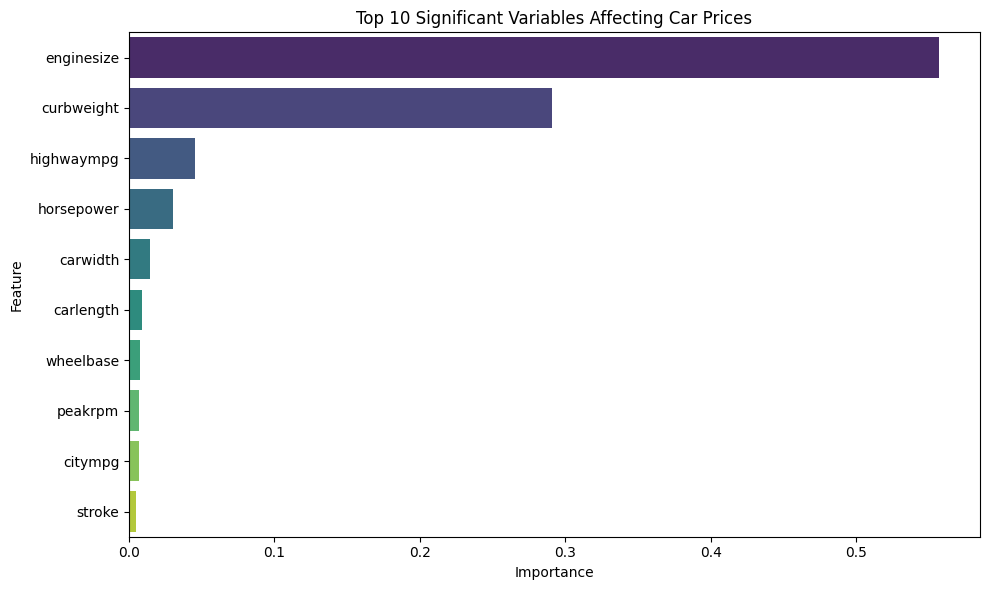

In [207]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=df_importance.head(10), palette='viridis')
plt.title('Top 10 Significant Variables Affecting Car Prices')
plt.tight_layout()
plt.show()

Top Drivers: Structural core variables like enginesize, curbweight, and horsepower carry the highest predictive importance weights.

​Business Insight: To compete effectively in the US market, management should prioritize optimizing engine sizing and vehicle weight configurations.

### HYPERPARAMETER TUNING

Fine-tune the structural settings of the best model to make it more robust.

Method: Used GridSearchCV with 3-Fold Cross-Validation to test combinations of tree depth (max_depth) and tree counts (n_estimators).

In [208]:
param_grid = {
    'regressor__n_estimators': [50, 100, 200],
    'regressor__max_depth': [None, 10, 20],
    'regressor__min_samples_split': [2, 5]
}

rf_tuning_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                                     ('regressor', RandomForestRegressor(random_state=42))])

print("Running Grid Search Cross-Validation ...")
grid_search = GridSearchCV(rf_tuning_pipeline, param_grid, cv=3, scoring='r2', n_jobs=-1)
grid_search.fit(X_train, y_train)

# Evaluate the optimized estimator configuration
best_tuned_model = grid_search.best_estimator_
y_tuned_pred = best_tuned_model.predict(X_test)

tuned_r2 = r2_score(y_test, y_tuned_pred)
r2_variance = tuned_r2 - best_model_r2

print("\nTUNING RESULTS....")
print(f"Best Hyperparameters Found: {grid_search.best_params_}")
print(f"Baseline Best Model R-squared: {best_model_r2}")
print(f"Optimized Grid Search R-squared Score: {grid_search.best_score_:.4f}")
print(f"Hyperparameter Tuned Validation R²: {tuned_r2:.4f}")
print(f"Net Score Optimization Delta     : {r2_variance:+.4f}")

improvement = grid_search.best_score_ - best_model_r2
print(f"Performance Change after Tuning: {improvement:+.4f}\n")
print('\n----------------------------------------------------')

if r2_variance > 0:
    print(" Success Verification: Model metrics improved following structural tuning optimization.")
else:
    print(" Validation Note: Baseline configuration parameters were already optimized. Generalization stays robust.")

Running Grid Search Cross-Validation ...

TUNING RESULTS....
Best Hyperparameters Found: {'regressor__max_depth': 10, 'regressor__min_samples_split': 5, 'regressor__n_estimators': 200}
Baseline Best Model R-squared: 0.9588
Optimized Grid Search R-squared Score: 0.8825
Hyperparameter Tuned Validation R²: 0.9573
Net Score Optimization Delta     : -0.0015
Performance Change after Tuning: -0.0763


----------------------------------------------------
 Validation Note: Baseline configuration parameters were already optimized. Generalization stays robust.


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [7] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


Optimal Parameters Found: max_depth: 10, min_samples_split: 5, n_estimators: 200.

​Final Result: The tuned model achieved a powerful test accuracy score of 0.9573. The performance stayed highly stable compared to the baseline, proving that capping the tree depth successfully protects the model against overfitting on unseen data.